<a href="https://colab.research.google.com/github/Rojakarilakshmiprasanna/11239A077_OPENCV_LAB_OBSERVATION/blob/main/Experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving strawberry_rotten_005.jpg (3).jpg to strawberry_rotten_005.jpg (3) (2).jpg


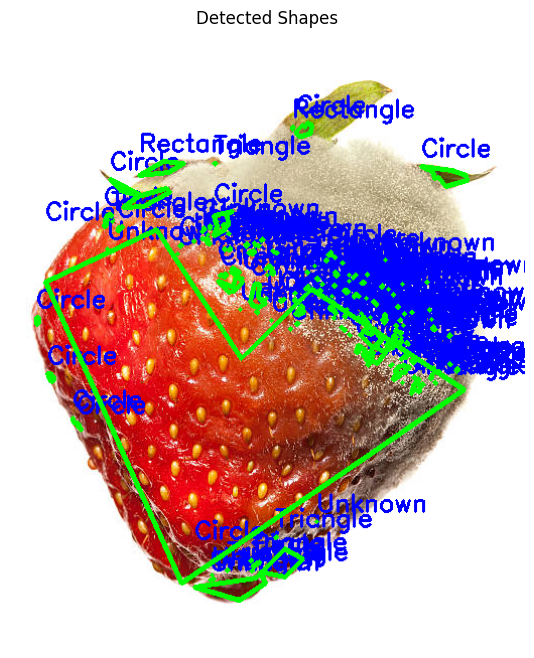

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Step 2: Read image
img = cv2.imread(filename)
img_draw = img.copy()  # Copy for drawing contours

# Step 3: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Apply Gaussian Blur to remove noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Step 5: Apply Thresholding
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

# Step 6: Detect contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 7: Shape detection
for cnt in contours:
    # Approximate the contour
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    x, y, w, h = cv2.boundingRect(approx)

    # Identify shape based on number of vertices
    if len(approx) == 3:
        shape_name = "Triangle"
    elif len(approx) == 4:
        # Check aspect ratio to distinguish square vs rectangle
        aspect_ratio = w / float(h)
        if 0.95 <= aspect_ratio <= 1.05:
            shape_name = "Square"
        else:
            shape_name = "Rectangle"
    elif len(approx) > 4:
        shape_name = "Circle"
    else:
        shape_name = "Unknown"

    # Draw contour and label
    cv2.drawContours(img_draw, [approx], 0, (0,255,0), 3)
    cv2.putText(img_draw, shape_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255,0,0), 2)

# Step 8: Display results
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Detected Shapes")
plt.axis('off')
plt.show()

Saving strawberry_rotten_005.jpg (3).jpg to strawberry_rotten_005.jpg (3) (1).jpg


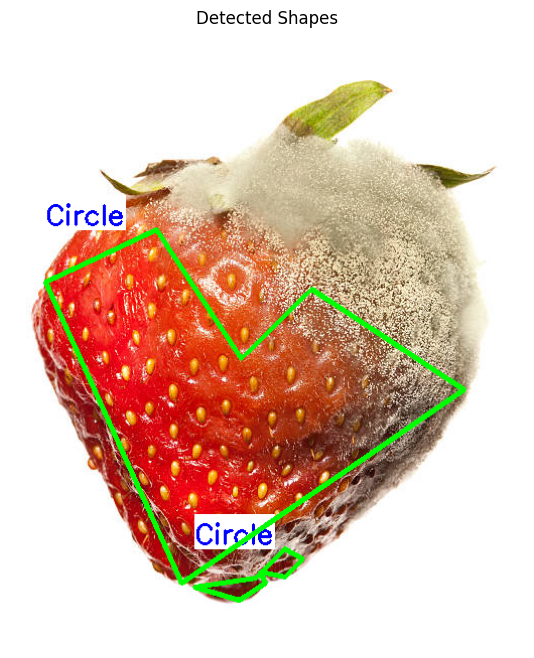

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Step 2: Read image
img = cv2.imread(filename)
img_draw = img.copy()  # Copy for drawing contours

# Step 3: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Apply Gaussian Blur to remove noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 5: Apply Thresholding (invert binary for contour detection)
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

# Step 6: Detect contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Minimum contour area to filter noise
min_contour_area = 500  # Adjust this depending on your image scale

# Step 7: Shape detection and drawing
for cnt in contours:
    if cv2.contourArea(cnt) < min_contour_area:
        continue  # Skip small noise contours

    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    x, y, w, h = cv2.boundingRect(approx)

    # Identify shape
    if len(approx) == 3:
        shape_name = "Triangle"
    elif len(approx) == 4:
        aspect_ratio = w / float(h)
        shape_name = "Square" if 0.95 <= aspect_ratio <= 1.05 else "Rectangle"
    elif len(approx) > 4:
        shape_name = "Circle"
    else:
        shape_name = "Unknown"

    # Draw contour with thickness 4
    cv2.drawContours(img_draw, [approx], 0, (0, 255, 0), 4)

    # Draw filled rectangle behind text for readability
    (text_width, text_height), baseline = cv2.getTextSize(shape_name, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
    cv2.rectangle(img_draw, (x, y - text_height - baseline - 5), (x + text_width, y), (255, 255, 255), -1)

    # Put text label with blue color, bigger font and thickness
    cv2.putText(img_draw, shape_name, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

# Step 8: Display results
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Detected Shapes")
plt.axis('off')
plt.show()